<div style="border-left: 6px solid #00cfff; 
background: linear-gradient(90deg, #0f2027, #203a43); 
padding: 20px; 
color: #b3f5ff; 
font-size: 40px; 
font-family: 'Segoe UI', sans-serif; 
font-weight: 400; 
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<b style="color: #00cfff;">⚡</b> 
<span style="color: #ffffff;">Exercícios Aprendizado Produnfo</span>
</div>

<div style="border-left: 6px solid #00cfff; 
background: linear-gradient(90deg, #0f2027, #203a43); 
padding: 20px; 
color: #b3f5ff; 
font-size: 22px; 
font-family: 'Segoe UI', sans-serif; 
font-weight: 300; 
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">1) Implemente uma Rede Perceptron de Múltiplas Camadas que faça a predição se um
passageiro sobreviveu ou não ao acidente do Titanic.</span>
</div>

In [2]:
# Importação das bibliotecas necessárias
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Balanceamento (se necessário)
from imblearn.over_sampling import SMOTE

# Rede Neural MLP
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Para suprimir warnings
import warnings
warnings.filterwarnings('ignore')

# Configuração estética para plots
sns.set_style('whitegrid')

<div style="border-left: 6px solid #00cfff; 
background: linear-gradient(90deg, #0f2027, #203a43); 
padding: 20px; 
color: #b3f5ff; 
font-size: 18px; 
font-family: 'Segoe UI', sans-serif; 
font-weight: 300; 
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">Carregamento e Exploração Inicial do Dataset</span>
</div>

Conjunto de treino:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Informações do dataset de treino:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Estatísticas descritivas:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Valores ausentes por coluna no treino:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Distribuição de Survived:


Survived
0    549
1    342
Name: count, dtype: int64

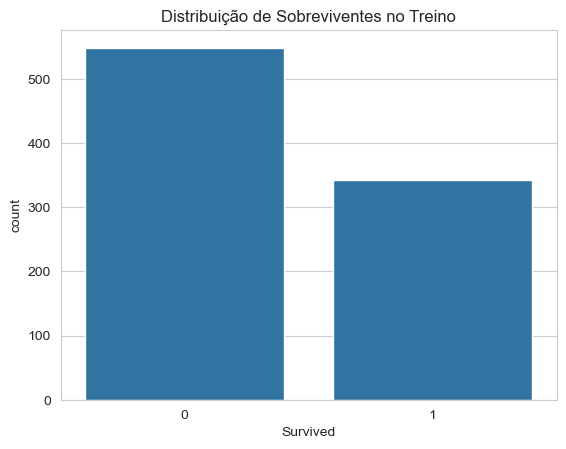

In [7]:
# Caminhos dos arquivos (substitua pelos seus caminhos se necessário)
train_path = r"C:\Users\kenny\OneDrive\Documentos\UFPB\P9\Aprendizado Profundo\titanic\train.csv"
test_path = r"C:\Users\kenny\OneDrive\Documentos\UFPB\P9\Aprendizado Profundo\titanic\test.csv"
gender_path = r"C:\Users\kenny\OneDrive\Documentos\UFPB\P9\Aprendizado Profundo\titanic\gender_submission.csv"

# Carregar os datasets
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
gender_df = pd.read_csv(gender_path)

# Visualizar as primeiras linhas do conjunto de treino
print("Conjunto de treino:")
display(train_df.head())

# Informações gerais do conjunto de treino
print("\nInformações do dataset de treino:")
train_df.info()

# Estatísticas descritivas
print("\nEstatísticas descritivas:")
display(train_df.describe())

# Verificar valores ausentes
print("\nValores ausentes por coluna no treino:")
display(train_df.isnull().sum())

# Distribuição da variável alvo
print("\nDistribuição de Survived:")
display(train_df['Survived'].value_counts())

# Visualização rápida da distribuição
sns.countplot(x='Survived', data=train_df)
plt.title("Distribuição de Sobreviventes no Treino")
plt.show()

<div style="border-left: 6px solid #00cfff; 
background: linear-gradient(90deg, #0f2027, #203a43); 
padding: 20px; 
color: #b3f5ff; 
font-size: 18px; 
font-family: 'Segoe UI', sans-serif; 
font-weight: 300; 
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">Pré-processamento do Dataset</span>
</div>

In [11]:
# 1️⃣ Remover colunas irrelevantes
train_df_proc = train_df.drop(columns=['PassengerId', 'Name', 'Ticket'])
test_df_proc = test_df.drop(columns=['PassengerId', 'Name', 'Ticket'])

# 2️⃣ Tratar Cabin: criar feature simplificada "CabinKnown"
train_df_proc['CabinKnown'] = train_df_proc['Cabin'].notnull().astype(int)
test_df_proc['CabinKnown'] = test_df_proc['Cabin'].notnull().astype(int)

# Podemos descartar a coluna original Cabin
train_df_proc = train_df_proc.drop(columns=['Cabin'])
test_df_proc = test_df_proc.drop(columns=['Cabin'])

# 3️⃣ Separar features e target
X = train_df_proc.drop('Survived', axis=1)
y = train_df_proc['Survived']

# 4️⃣ Identificar colunas numéricas e categóricas
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']
categorical_features = ['Sex', 'Embarked', 'CabinKnown']

# 5️⃣ Criar pipeline para pré-processamento
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Preenche Age ausente com mediana
    ('scaler', StandardScaler())                    # Padroniza as variáveis numéricas
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Preenche Embarked ausente
    ('onehot', OneHotEncoder(handle_unknown='ignore'))     # One-hot encoding
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 6️⃣ Aplicar pré-processamento no conjunto de treino e teste
X_processed = preprocessor.fit_transform(X)
test_processed = preprocessor.transform(test_df_proc)

# 7️⃣ Dividir em treino e validação
X_train, X_val, y_train, y_val = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

# 8️⃣ Balanceamento do conjunto de treino (SMOTE)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# 9️⃣ Visualizar forma dos arrays finais
print("Shape X_train_bal:", X_train_bal.shape)
print("Shape y_train_bal:", y_train_bal.shape)
print("Shape X_val:", X_val.shape)
print("Shape y_val:", y_val.shape)

Shape X_train_bal: (878, 11)
Shape y_train_bal: (878,)
Shape X_val: (179, 11)
Shape y_val: (179,)


<div style="border-left: 6px solid #00cfff; 
background: linear-gradient(90deg, #0f2027, #203a43); 
padding: 20px; 
color: #b3f5ff; 
font-size: 18px; 
font-family: 'Segoe UI', sans-serif; 
font-weight: 300; 
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">Implementação de uma Multilayer Perceptron (MLP)</span>
</div>

Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4989 - loss: 0.7163 - val_accuracy: 0.3911 - val_loss: 0.7012
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5900 - loss: 0.6559 - val_accuracy: 0.7039 - val_loss: 0.6480
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6743 - loss: 0.6246 - val_accuracy: 0.7263 - val_loss: 0.6135
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7130 - loss: 0.5895 - val_accuracy: 0.7486 - val_loss: 0.5847
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7563 - loss: 0.5535 - val_accuracy: 0.7430 - val_loss: 0.5491
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7677 - loss: 0.5282 - val_accuracy: 0.7654 - val_loss: 0.5201
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7916 - loss: 0.5082 - val_accuracy: 0.7709 - val_loss: 0.5041
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7756 - loss: 0.5015 - val_accuracy: 0.7765 - val_loss

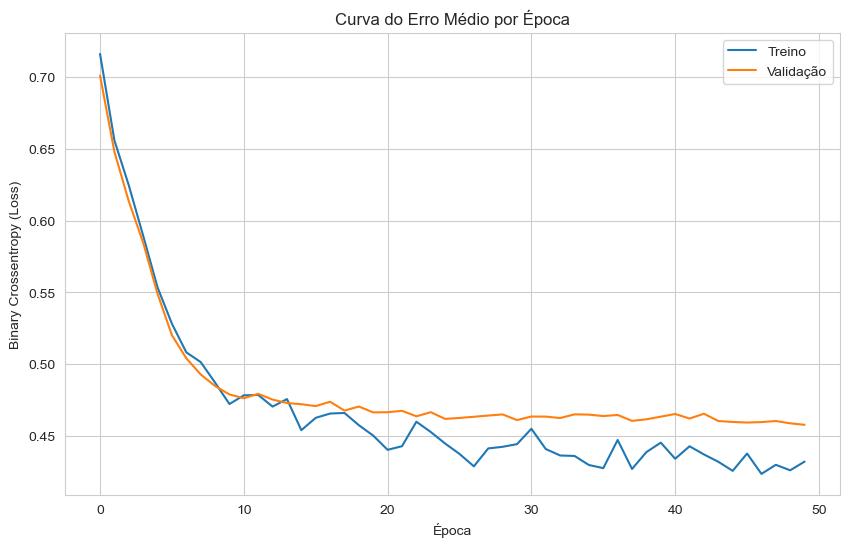

In [13]:
# 1️⃣ Definir a arquitetura do modelo MLP
input_dim = X_train_bal.shape[1]  # número de features após pré-processamento

model = Sequential([
    Dense(32, input_dim=input_dim, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # saída binária
])

# 2️⃣ Compilar o modelo
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3️⃣ Treinar o modelo
history = model.fit(
    X_train_bal, y_train_bal,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

# 4️⃣ Plotar curva do erro médio (loss) treino x validação
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title("Curva do Erro Médio por Época")
plt.xlabel("Época")
plt.ylabel("Binary Crossentropy (Loss)")
plt.legend()
plt.show()

<div style="border-left: 6px solid #00cfff; 
background: linear-gradient(90deg, #0f2027, #203a43); 
padding: 20px; 
color: #b3f5ff; 
font-size: 18px; 
font-family: 'Segoe UI', sans-serif; 
font-weight: 300; 
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">Avaliação Final</span>
</div>

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


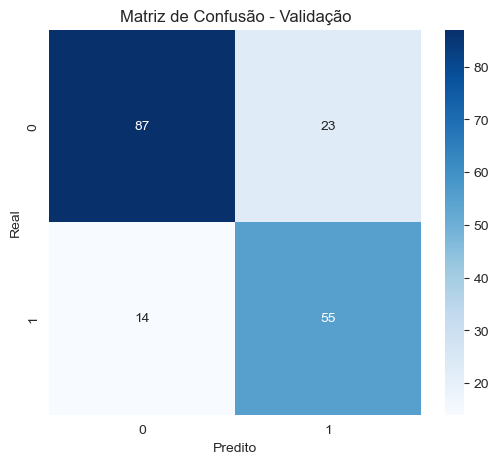

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.86      0.79      0.82       110
           1       0.71      0.80      0.75        69

    accuracy                           0.79       179
   macro avg       0.78      0.79      0.79       179
weighted avg       0.80      0.79      0.80       179

Accuracy no conjunto de validação: 0.7933


In [16]:
# 1️⃣ Predição no conjunto de validação
y_pred_prob = model.predict(X_val)
y_pred = (y_pred_prob >= 0.5).astype(int).reshape(-1)

# 2️⃣ Matriz de confusão
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão - Validação")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

# 3️⃣ Relatório de classificação
print("Relatório de Classificação:")
print(classification_report(y_val, y_pred))

# 4️⃣ Accuracy
acc = accuracy_score(y_val, y_pred)
print(f"Accuracy no conjunto de validação: {acc:.4f}")